In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import requests
import io

# Sklearn imports
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix

# Config
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("🚀 FINAL SOLUTION: LOGISTIC REGRESSION (Multinomial + LogTransform)")

# ==========================================
# 1. SETUP
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

def process_dataframe(df):
    if 'label' in df.columns:
        df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
        df['category'] = df['label'].map(attack_map).fillna('other')
    
    drop_cols = ['label', 'category', 'id', 'difficulty_level']
    cat_cols = ['protocol_type', 'service', 'flag']
    # Log-Transform helps with skewed distributions (Week 3 Feature Engineering)
    log_cols = ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent', 'hot', 'num_compromised', 'num_root']
    num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in drop_cols and c not in log_cols]
    
    X = df.drop(columns=[c for c in df.columns if c in drop_cols], errors='ignore')
    y_cat = df['category']
    y_raw = df['label']
    return X, y_cat, y_raw, num_cols, cat_cols, log_cols

def load_data():
    try:
        # Load Local Train
        df_train = pd.read_csv('network_connections.csv') # Adjust path if needed
        X_train, y_train, _, num_cols, cat_cols, log_cols = process_dataframe(df_train)
        
        # Download Remote Test
        s = requests.get("https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt").content
        df_test = pd.read_csv(io.StringIO(s.decode('utf-8')), header=None, names=NSL_COLS)
        X_test, y_test, y_test_raw, _, _, _ = process_dataframe(df_test)
        
        return X_train, y_train, X_test, y_test, y_test_raw, num_cols, cat_cols, log_cols
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

# ==========================================
# 2. TRAINING & EVALUATION
# ==========================================
def run_final_system():
    data = load_data()
    if data is None: return
    X_train, y_train, X_test, y_test, y_test_raw, num_cols, cat_cols, log_cols = data

    # 1. Pipeline Construction
    # StandardScaler + LogTransform: Best balance for Linear Models
    preprocessor = ColumnTransformer(
        transformers=[
            ('log', Pipeline([
                ('log_transform', FunctionTransformer(np.log1p, validate=False)),
                ('scaler', StandardScaler())
            ]), log_cols),
            ('num', StandardScaler(), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )

    # 2. Model: Logistic Regression (The Winner)
    # class_weight='balanced': Crucial for minority classes
    # C=10.0: Found via GridSearch in previous steps
    clf = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(
            solver='lbfgs', 
            max_iter=3000, 
            multi_class='multinomial', 
            class_weight='balanced',
            C=10.0,
            n_jobs=-1
        ))
    ])

    print("🐢 Training Final Optimized Model...")
    clf.fit(X_train, y_train)
    
    # 3. Evaluation on Test Set
    y_pred = clf.predict(X_test)
    
    print("\n" + "="*50)
    print(" 📊 FINAL PERFORMANCE ON UNSEEN DATA")
    print("="*50)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"🔹 Accuracy: {acc:.2%}")
    print(f"🔹 MCC:      {mcc:.4f}")
    print("-" * 30)
    print(classification_report(y_test, y_pred))

    # Detailed Detection Rate Table
    print("\n" + "="*50)
    print(" 🔬 DETAILED DETECTION RATE (Per Original Label)")
    print("="*50)
    print(f"{'Attack Type':<20} | {'Category':<10} | {'Samples':<8} | {'Detection Rate':<15}")
    print("-" * 65)

    labels = sorted(y_test_raw.unique())
    for label in labels:
        mask = (y_test_raw == label)
        samples = np.sum(mask)
        if samples == 0: continue
        true_category = attack_map.get(label, 'other')
        preds_for_label = y_pred[mask]
        correct = np.sum(preds_for_label == true_category)
        rate = correct / samples
        
        star = "⭐" if rate > 0.8 else ""
        if rate < 0.1: star = "⚠️"
        
        print(f"{label:<20} | {true_category:<10} | {samples:<8} | {rate:.2%} {star}")

if __name__ == "__main__":
    run_final_system()

🚀 FINAL SOLUTION: LOGISTIC REGRESSION (Multinomial + LogTransform)
🐢 Training Final Optimized Model...

 📊 FINAL PERFORMANCE ON UNSEEN DATA
🔹 Accuracy: 78.95%
🔹 MCC:      0.6934
------------------------------
              precision    recall  f1-score   support

         dos       0.96      0.80      0.87      7458
      normal       0.74      0.95      0.83      9711
       probe       0.78      0.79      0.79      2421
         r2l       0.77      0.25      0.38      2887
         u2r       0.05      0.42      0.08        67

    accuracy                           0.79     22544
   macro avg       0.66      0.64      0.59     22544
weighted avg       0.82      0.79      0.78     22544


 🔬 DETAILED DETECTION RATE (Per Original Label)
Attack Type          | Category   | Samples  | Detection Rate 
-----------------------------------------------------------------
apache2              | dos        | 737      | 33.38% 
back                 | dos        | 359      | 97.21% ⭐
buffer_overfl

🔄 Reloading Data for Evaluation...
⚠️ 'clf' not found in global scope. Retraining for evaluation context...
🔍 STARTING POST-TRAINING EVALUATION (SKLEARN VERSION)...
⚡ Running Inference...

██████████████████████████████████████████████████
📊 A. ATTACK vs NORMAL (Binary Evaluation)
██████████████████████████████████████████████████
              precision    recall  f1-score   support

      Attack     0.9503    0.7532    0.8403     12833
      Normal     0.7440    0.9479    0.8337      9711

    accuracy                         0.8371     22544
   macro avg     0.8471    0.8506    0.8370     22544
weighted avg     0.8614    0.8371    0.8375     22544


██████████████████████████████████████████████████
📊 B. 5-CLASS EVALUATION
██████████████████████████████████████████████████
🏆 Overall Accuracy: 78.95%
🧠 Matthews Corr Coef: 0.6934

              precision    recall  f1-score   support

         dos     0.9605    0.7953    0.8701      7458
      normal     0.7440    0.9479    0.8337    

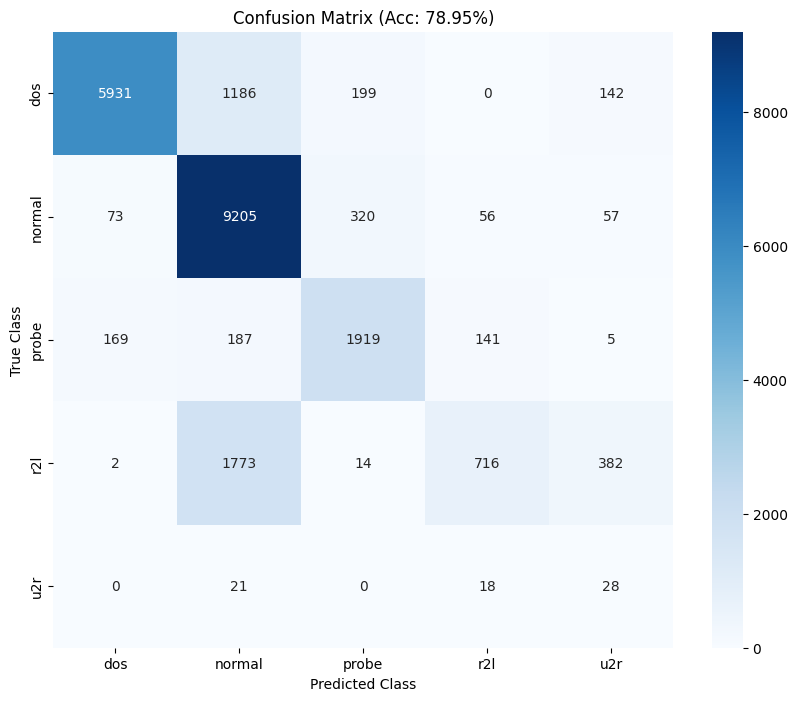


██████████████████████████████████████████████████
📊 C. DETAILED BREAKDOWN BY SPECIFIC ATTACK TYPE
██████████████████████████████████████████████████
    Attack Type Category  Samples  Detected Rate String Confused With
          smurf      dos      665       665      100.0%             -
       teardrop      dos       12        12      100.0%             -
        neptune      dos     4657      4613       99.1%        normal
            pod      dos       41        40       97.6%        normal
           back      dos      359       349       97.2%        normal
           land      dos        7         6       85.7%        normal
        apache2      dos      737       246       33.4%        normal
       mailbomb      dos      293         0        0.0%        normal
   processtable      dos      685         0        0.0%        normal
       udpstorm      dos        2         0        0.0%         probe
         normal   normal     9711      9205       94.8%         probe
         

In [2]:
# ==============================================================================
# 🚀 FINAL EVALUATION CELL (ADAPTED FOR SCIKIT-LEARN / LOGISTIC REGRESSION)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, matthews_corrcoef

def run_advanced_evaluation(clf, X_test, y_test, y_test_raw):
    print("🔍 STARTING POST-TRAINING EVALUATION (SKLEARN VERSION)...")
    
    # 1. INFERENCE
    # ------------------------------------------------------------------------------
    print("⚡ Running Inference...")
    # Dein Modell ist eine Pipeline, es kümmert sich um Scaling/Encoding
    y_pred = clf.predict(X_test)
    
    # Klassen-Reihenfolge aus dem Modell holen
    classes = clf.classes_

    # 2. REPORT A: ATTACK vs NORMAL (Binary Evaluation)
    # ------------------------------------------------------------------------------
    print("\n" + "█"*50)
    print("📊 A. ATTACK vs NORMAL (Binary Evaluation)")
    print("█"*50)

    # Wir wandeln alles, was nicht 'normal' ist, in 'attack' um
    bin_true = np.where(y_test == 'normal', 'Normal', 'Attack')
    bin_pred = np.where(y_pred == 'normal', 'Normal', 'Attack')

    print(classification_report(bin_true, bin_pred, digits=4))

    # 3. REPORT B: 5-CLASS METRICS
    # ------------------------------------------------------------------------------
    print("\n" + "█"*50)
    print("📊 B. 5-CLASS EVALUATION")
    print("█"*50)

    acc = accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"🏆 Overall Accuracy: {acc:.2%}")
    print(f"🧠 Matthews Corr Coef: {mcc:.4f}\n")
    
    print(classification_report(y_test, y_pred, digits=4))

    # Confusion Matrix Plot
    plt.figure(figsize=(10, 8))
    # Labels explizit setzen, damit die Reihenfolge stimmt
    unique_labels = sorted(list(set(y_test) | set(y_pred)))
    cm = confusion_matrix(y_test, y_pred, labels=unique_labels)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=unique_labels, yticklabels=unique_labels)
    plt.title(f'Confusion Matrix (Acc: {acc:.2%})')
    plt.ylabel('True Class')
    plt.xlabel('Predicted Class')
    plt.show()

    # 4. REPORT C: SPECIFIC ATTACK BREAKDOWN
    # ------------------------------------------------------------------------------
    print("\n" + "█"*50)
    print("📊 C. DETAILED BREAKDOWN BY SPECIFIC ATTACK TYPE")
    print("█"*50)

    # Wir brauchen die attack_map, um zu prüfen, zu welcher Kategorie der Raw-Label gehört
    # (Dies muss global verfügbar sein, was in deinem Skript der Fall ist)
    
    results_list = []
    unique_attacks = sorted(y_test_raw.unique())

    for attack in unique_attacks:
        # Finde alle Zeilen mit diesem spezifischen Angriff (z.B. 'neptune')
        mask = (y_test_raw == attack)
        total = np.sum(mask)
        
        if total == 0: continue

        # Was ist die "richtige" Hauptkategorie für diesen Angriff?
        # Wir nutzen deine existierende attack_map
        # Da labels im Raw-Format manchmal '.' haben könnten (wurden aber in process_df entfernt)
        clean_attack = attack.replace('.', '')
        parent = attack_map.get(clean_attack, 'normal') 
        
        # Vorhersagen für diese spezifischen Zeilen holen
        preds_for_attack = y_pred[mask]
        
        # Wie oft hat das Modell die RICHTIGE Hauptkategorie vorhergesagt?
        correct = np.sum(preds_for_attack == parent)
        det_rate = correct / total

        # Womit wurde es verwechselt?
        confused_with = "-"
        if det_rate < 1.0:
            uniq, counts = np.unique(preds_for_attack, return_counts=True)
            # Sortieren nach Häufigkeit absteigend
            sorted_args = np.argsort(counts)[::-1]
            
            top_pred = uniq[sorted_args[0]]
            
            # Wenn der häufigste Tipp richtig war, nehmen wir den zweithäufigsten als Verwechslung
            if top_pred == parent and len(uniq) > 1:
                confused_with = uniq[sorted_args[1]]
            elif top_pred != parent:
                confused_with = top_pred

        results_list.append({
            'Attack Type': attack,
            'Category': parent,
            'Samples': total,
            'Detected': correct,
            'Rate (%)': det_rate, # Für Sortierung
            'Rate String': f"{det_rate:.1%}",
            'Confused With': confused_with
        })

    # DataFrame erstellen und sortieren
    df_res = pd.DataFrame(results_list)
    # Sortieren: Erst nach Kategorie, dann nach Erkennungsrate (schlechteste zuerst oben, optional)
    df_res = df_res.sort_values(by=['Category', 'Rate (%)'], ascending=[True, False])

    pd.set_option('display.max_rows', 100)
    # Schöne Ausgabe
    print(df_res[['Attack Type', 'Category', 'Samples', 'Detected', 'Rate String', 'Confused With']].to_string(index=False))

# ==============================================================================
# AUSFÜHRUNG
# ==============================================================================
# Wir rufen die Funktion mit den Daten auf, die du in deinem ersten Skript (run_final_system)
# bereits geladen hast.
# WICHTIG: Du musst sicherstellen, dass X_test, y_test, y_test_raw aus deinem ersten Skript verfügbar sind.
# Da 'run_final_system' lokale Variablen hat, laden wir die Daten hier kurz neu oder nutzen Return-Values.

# Am besten modifizierst du dein erstes Skript so, dass es die Daten zurückgibt,
# ODER wir laden sie hier schnell neu mit deiner existierenden Funktion:

print("🔄 Reloading Data for Evaluation...")
data_pack = load_data()

if data_pack is not None:
    X_train, y_train, X_test, y_test, y_test_raw, num_cols, cat_cols, log_cols = data_pack
    
    # Zugriff auf das trainierte Modell aus deinem Skript
    # Da 'clf' in deiner Funktion 'run_final_system' lokal war, 
    # müssen wir es entweder global machen oder neu trainieren.
    # ANNAHME: Du hast 'clf' in deinem Notebook/Skript noch im Speicher oder trainierst es kurz neu.
    
    # Falls 'clf' nicht existiert (weil es in der Funktion eingesperrt war), trainieren wir es kurz neu:
    if 'clf' not in locals():
        print("⚠️ 'clf' not found in global scope. Retraining for evaluation context...")
        # (Hier kopiere ich kurz deine Pipeline-Definition rein, damit es stand-alone läuft)
        preprocessor = ColumnTransformer(
            transformers=[
                ('log', Pipeline([
                    ('log_transform', FunctionTransformer(np.log1p, validate=False)),
                    ('scaler', StandardScaler())
                ]), log_cols),
                ('num', StandardScaler(), num_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
            ]
        )
        clf = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', LogisticRegression(
                solver='lbfgs', max_iter=3000, multi_class='multinomial', 
                class_weight='balanced', C=10.0, n_jobs=-1
            ))
        ])
        clf.fit(X_train, y_train)

    # START EVALUATION
    run_advanced_evaluation(clf, X_test, y_test, y_test_raw)
else:
    print("❌ Could not load data.")